# Jaguar Re-ID — CNN Contrastive Learning (Triplet Loss)

**Architecture** : 5x(Conv2D + BatchNorm + MaxPool2D) → GlobalAveragePooling2D → Dropout(0.5) → Dense(128) → L2 Normalize  
**Base** : même backbone CNN que v5, mais entraîné avec **Batch-Hard Triplet Loss** au lieu de cross-entropy  
**Objectif** : optimiser directement la qualité des embeddings pour le re-ID, au lieu de passer par un proxy de classification  

### Pourquoi cette expérience ?

En v5, on a observé un **décalage entre val_acc (91%) et Kaggle score (0.404)** : le modèle classifie bien mais ses embeddings ne sont pas optimaux pour la similarité cosinus. La cross-entropy optimise la séparabilité des classes (frontières de décision), pas la compacité intra-classe ni la marge inter-classe — deux propriétés essentielles pour le re-ID.

La **Triplet Loss** attaque ce problème directement : pour chaque image (anchor), elle pousse les images du même jaguar plus près (positive) et les images de jaguars différents plus loin (negative) dans l'espace d'embedding.

## 1. Setup & data loading

In [1]:
import sys, os, glob
sys.path.insert(0, os.path.join(os.getcwd(), '..'))

# GPU setup — LD_LIBRARY_PATH must be set before TF loads CUDA
nvidia_libs = glob.glob(os.path.join(sys.prefix, 'lib/python*/site-packages/nvidia/*/lib'))
if nvidia_libs:
    os.environ['LD_LIBRARY_PATH'] = ':'.join(nvidia_libs) + ':' + os.environ.get('LD_LIBRARY_PATH', '')
os.environ['CUDA_VISIBLE_DEVICES'] = '1'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, optimizers, callbacks
from sklearn.preprocessing import normalize

# Memory growth — avoid grabbing all VRAM at once (other processes may be running)
for gpu in tf.config.list_physical_devices('GPU'):
    tf.config.experimental.set_memory_growth(gpu, True)

from src.config import *
from src.data import load_data, load_test_pairs, make_dataset

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(SUBMISSION_DIR, exist_ok=True)
os.makedirs(LOG_DIR, exist_ok=True)

tf.random.set_seed(SEED)
np.random.seed(SEED)

print(f"TensorFlow: {tf.__version__}")
gpus = tf.config.list_physical_devices('GPU')
print(f"GPU: {gpus}")
if not gpus:
    print("WARNING: No GPU detected, training will be slow on CPU!")
    print("Run this in terminal first: export LD_LIBRARY_PATH=$(python3 -c \"import glob; print(':'.join(glob.glob('env/lib/python*/site-packages/nvidia/*/lib')))\")") 
    print("Then restart the Jupyter kernel.")

I0000 00:00:1776172594.346206 1856072 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow: 2.21.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
MODEL_NAME   = 'cnn_contrastive'
AUGMENTATION = 'moderate'
CL_BATCH_SIZE = 128   # batch large pour garantir des paires positives (31 classes → ~4 imgs/classe/batch)
MARGIN = 0.3           # marge pour la triplet loss
EMBEDDING_DIM = 128

In [3]:
X_train, y_train = load_data('train')
X_val, y_val     = load_data('val')
test_pairs_df = load_test_pairs()

# Batch size = 128 pour le contrastive learning
train_ds = make_dataset(X_train, y_train, training=True, augmentation=AUGMENTATION, batch_size=CL_BATCH_SIZE)
val_ds   = make_dataset(X_val, y_val, batch_size=CL_BATCH_SIZE)

print(f"Train: {X_train.shape} | Val: {X_val.shape}")
print(f"Train batches: {len(train_ds)} | Val batches: {len(val_ds)}")
print(f"Batch size: {CL_BATCH_SIZE}")

# Vérification : chaque batch a assez de classes pour former des triplets
for x_batch, y_batch in train_ds.take(1):
    unique_classes = len(np.unique(y_batch.numpy()))
    print(f"Classes dans un batch: {unique_classes}/31")

I0000 00:00:1776172602.569201 1856072 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 46758 MB memory:  -> device: 0, name: NVIDIA RTX A6000, pci bus id: 0000:86:00.0, compute capability: 8.6
W0000 00:00:1776172602.576310 1856072 cpu_allocator_impl.cc:82] Allocation of 912801792 exceeds 10% of free system memory.
W0000 00:00:1776172603.692137 1856072 cpu_allocator_impl.cc:82] Allocation of 912801792 exceeds 10% of free system memory.


Train: (1516, 224, 224, 3) | Val: (379, 224, 224, 3)
Train batches: 12 | Val batches: 3
Batch size: 128


W0000 00:00:1776172607.049697 1856072 cpu_allocator_impl.cc:82] Allocation of 912801792 exceeds 10% of free system memory.


Classes dans un batch: 25/31


## 2. Model architecture

In [4]:
from tensorflow.keras.regularizers import l2

def build_embedding_model():
    """Même backbone CNN que v5, mais sans tête softmax.
    Sortie : embedding L2-normalisé de dimension 128."""
    model = keras.Sequential([
        layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

        layers.Conv2D(32, 3, activation='relu', padding='same', kernel_regularizer=l2(1e-4)),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),

        layers.Conv2D(64, 3, activation='relu', padding='same', kernel_regularizer=l2(1e-4)),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),

        layers.Conv2D(128, 3, activation='relu', padding='same', kernel_regularizer=l2(1e-4)),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),

        layers.Conv2D(256, 3, activation='relu', padding='same', kernel_regularizer=l2(1e-4)),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),

        layers.Conv2D(512, 3, activation='relu', padding='same', kernel_regularizer=l2(1e-4)),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),

        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.5),
        layers.Dense(EMBEDDING_DIM, activation='relu'),
        layers.Lambda(lambda x: tf.math.l2_normalize(x, axis=1))  # L2 normalize
    ], name=MODEL_NAME)
    return model

model = build_embedding_model()
model.summary()

Model: "cnn_contrastive"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 14, 14, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 128)            │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,638,208 (6.25 MB)

 Trainable params: 1,636,224 (6.24 MB)

 Non-trainable params: 1,984 (7.75 KB)

## 3. Batch-Hard Triplet Loss

Pour chaque anchor dans le batch :
- **Hardest positive** : l'image du même jaguar la plus **éloignée** (max distance)
- **Hardest negative** : l'image d'un jaguar différent la plus **proche** (min distance)

Loss = max(0, d(anchor, hardest_pos) - d(anchor, hardest_neg) + margin)

C'est la stratégie de mining la plus agressive — elle force le modèle à résoudre les cas les plus difficiles à chaque step.

In [5]:
def pairwise_cosine_distance(embeddings):
    """Matrice NxN de distances cosinus (1 - similarity)."""
    similarity = tf.matmul(embeddings, embeddings, transpose_b=True)
    return 1.0 - similarity


def batch_hard_triplet_loss(labels, embeddings, margin=MARGIN):
    """Batch-hard triplet loss avec distance cosinus."""
    dist_matrix = pairwise_cosine_distance(embeddings)  # (B, B)
    
    labels = tf.cast(labels, tf.int32)
    # Mask: same class (positives) and different class (negatives)
    labels_eq = tf.equal(tf.expand_dims(labels, 0), tf.expand_dims(labels, 1))  # (B, B)
    labels_neq = tf.logical_not(labels_eq)
    
    # Exclude self-pairs for positives
    mask_self = tf.logical_not(tf.eye(tf.shape(labels)[0], dtype=tf.bool))
    mask_pos = tf.logical_and(labels_eq, mask_self)    # same class, not self
    mask_neg = labels_neq                               # different class
    
    # Hardest positive: max distance among same-class pairs
    # Set non-positive pairs to -1 so they don't affect max
    dist_pos = tf.where(mask_pos, dist_matrix, -1.0)
    hardest_pos = tf.reduce_max(dist_pos, axis=1)  # (B,)
    
    # Hardest negative: min distance among different-class pairs  
    # Set non-negative pairs to 2.0 (max cosine distance) so they don't affect min
    dist_neg = tf.where(mask_neg, dist_matrix, 2.0)
    hardest_neg = tf.reduce_min(dist_neg, axis=1)  # (B,)
    
    # Only count anchors that have at least one positive in the batch
    has_positive = tf.reduce_any(mask_pos, axis=1)  # (B,)
    
    triplet_loss = tf.maximum(hardest_pos - hardest_neg + margin, 0.0)
    triplet_loss = tf.where(has_positive, triplet_loss, 0.0)
    
    # Average only over valid anchors
    n_valid = tf.maximum(tf.reduce_sum(tf.cast(has_positive, tf.float32)), 1.0)
    return tf.reduce_sum(triplet_loss) / n_valid


def triplet_accuracy(labels, embeddings, margin=MARGIN):
    """Fraction des triplets correctement ordonnés (d_pos < d_neg)."""
    dist_matrix = pairwise_cosine_distance(embeddings)
    labels = tf.cast(labels, tf.int32)
    labels_eq = tf.equal(tf.expand_dims(labels, 0), tf.expand_dims(labels, 1))
    labels_neq = tf.logical_not(labels_eq)
    mask_self = tf.logical_not(tf.eye(tf.shape(labels)[0], dtype=tf.bool))
    mask_pos = tf.logical_and(labels_eq, mask_self)
    
    dist_pos = tf.where(mask_pos, dist_matrix, -1.0)
    hardest_pos = tf.reduce_max(dist_pos, axis=1)
    dist_neg = tf.where(labels_neq, dist_matrix, 2.0)
    hardest_neg = tf.reduce_min(dist_neg, axis=1)
    
    has_positive = tf.reduce_any(mask_pos, axis=1)
    correct = tf.logical_and(hardest_pos < hardest_neg, has_positive)
    n_valid = tf.maximum(tf.reduce_sum(tf.cast(has_positive, tf.float32)), 1.0)
    return tf.reduce_sum(tf.cast(correct, tf.float32)) / n_valid

## 4. Training

In [6]:
class TripletTrainer(keras.Model):
    """Wrapper pour entraîner avec triplet loss via model.fit()."""
    def __init__(self, embedding_model, margin=MARGIN):
        super().__init__()
        self.embedding_model = embedding_model
        self.margin = margin
        self.loss_tracker = keras.metrics.Mean(name='triplet_loss')
        self.acc_tracker = keras.metrics.Mean(name='triplet_acc')
    
    def call(self, inputs, training=False):
        return self.embedding_model(inputs, training=training)
    
    def train_step(self, data):
        images, labels = data
        with tf.GradientTape() as tape:
            embeddings = self.embedding_model(images, training=True)
            loss = batch_hard_triplet_loss(labels, embeddings, self.margin)
        
        grads = tape.gradient(loss, self.embedding_model.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.embedding_model.trainable_variables))
        
        acc = triplet_accuracy(labels, embeddings, self.margin)
        self.loss_tracker.update_state(loss)
        self.acc_tracker.update_state(acc)
        return {'triplet_loss': self.loss_tracker.result(), 'triplet_acc': self.acc_tracker.result()}
    
    def test_step(self, data):
        images, labels = data
        embeddings = self.embedding_model(images, training=False)
        loss = batch_hard_triplet_loss(labels, embeddings, self.margin)
        acc = triplet_accuracy(labels, embeddings, self.margin)
        self.loss_tracker.update_state(loss)
        self.acc_tracker.update_state(acc)
        return {'triplet_loss': self.loss_tracker.result(), 'triplet_acc': self.acc_tracker.result()}
    
    @property
    def metrics(self):
        return [self.loss_tracker, self.acc_tracker]

In [7]:
LR = 1e-4  # LR conservateur — la triplet loss est plus instable que la cross-entropy
EPOCHS = 80

trainer = TripletTrainer(model, margin=MARGIN)
trainer.compile(optimizer=optimizers.Adam(learning_rate=LR))

log_dir = os.path.join(LOG_DIR, MODEL_NAME, f'train_{datetime.now().strftime("%Y%m%d-%H%M%S")}')

history = trainer.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[
        callbacks.EarlyStopping(
            monitor='val_triplet_loss', patience=15, restore_best_weights=True, mode='min'
        ),
        callbacks.ReduceLROnPlateau(
            monitor='val_triplet_loss', factor=0.5, patience=7, min_lr=1e-6, verbose=1, mode='min'
        ),
        callbacks.TensorBoard(log_dir=log_dir),
    ],
    verbose=1
)

Epoch 1/80


W0000 00:00:1776172610.029973 1856072 cpu_allocator_impl.cc:82] Allocation of 912801792 exceeds 10% of free system memory.
I0000 00:00:1776172614.498618 1856749 service.cc:153] XLA service 0x7f627403c4d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776172614.498675 1856749 service.cc:161]   StreamExecutor [0]: NVIDIA RTX A6000, Compute Capability 8.6 (Driver: 12.6.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.20.0)
I0000 00:00:1776172614.604434 1856749 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1776172615.174232 1856749 cuda_dnn.cc:461] Loaded cuDNN version 92000
I0000 00:00:1776172615.294674 1856749 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_5045__.95
I0000 00:00:1776172616.923110 1856749 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does 

11/12 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - triplet_acc: 0.0037 - triplet_loss: 0.5158

I0000 00:00:1776172642.560841 1856749 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_5045__.95
I0000 00:00:1776172644.954301 1856749 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1776172645.902542 1856749 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1776172647.958781 1856749 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1776172649.364547

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - triplet_acc: 0.0037 - triplet_loss: 0.5145   

I0000 00:00:1776172670.046330 1856750 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.


12/12 ━━━━━━━━━━━━━━━━━━━━ 63s 3s/step - triplet_acc: 0.0027 - triplet_loss: 0.5000 - val_triplet_acc: 0.0278 - val_triplet_loss: 0.3047 - learning_rate: 1.0000e-04
Epoch 2/80
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 127ms/step - triplet_acc: 6.7751e-04 - triplet_loss: 0.4506 - val_triplet_acc: 0.0055 - val_triplet_loss: 0.3020 - learning_rate: 1.0000e-04
Epoch 3/80
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 132ms/step - triplet_acc: 0.0000e+00 - triplet_loss: 0.4191 - val_triplet_acc: 0.0081 - val_triplet_loss: 0.3016 - learning_rate: 1.0000e-04
Epoch 4/80
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 131ms/step - triplet_acc: 0.0000e+00 - triplet_loss: 0.3978 - val_triplet_acc: 0.0082 - val_triplet_loss: 0.3014 - learning_rate: 1.0000e-04
Epoch 5/80
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 128ms/step - triplet_acc: 0.0000e+00 - triplet_loss: 0.3824 - val_triplet_acc: 0.0027 - val_triplet_loss: 0.3012 - learning_rate: 1.0000e-04
Epoch 6/80
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 124ms/step - triplet_acc: 6.7751e-04 - triplet_loss: 0.3712 - val_

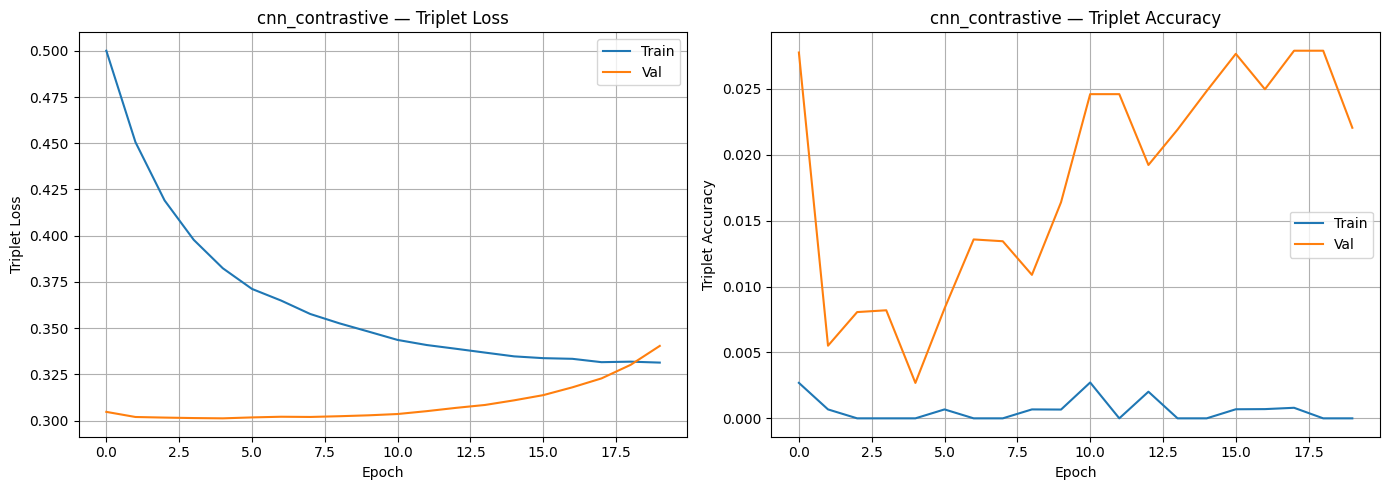

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['triplet_loss'],     label='Train')
axes[0].plot(history.history['val_triplet_loss'], label='Val')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Triplet Loss')
axes[0].set_title(f'{MODEL_NAME} — Triplet Loss'); axes[0].legend(); axes[0].grid(True)

axes[1].plot(history.history['triplet_acc'],     label='Train')
axes[1].plot(history.history['val_triplet_acc'], label='Val')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Triplet Accuracy')
axes[1].set_title(f'{MODEL_NAME} — Triplet Accuracy'); axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'{MODEL_NAME}_history.png'), dpi=150, bbox_inches='tight')
plt.show()

## 5. Evaluation — Rank-1 Retrieval Accuracy

Métrique standard en re-ID : pour chaque image query du val set, on cherche l'image la plus similaire parmi toutes les autres. Si c'est un jaguar du même individu → correct.

In [9]:
# Embeddings sur le val set
val_embeddings = model.predict(X_val, batch_size=CL_BATCH_SIZE, verbose=1)
val_embeddings_norm = normalize(val_embeddings, axis=1)

# Matrice de similarité cosinus (val x val)
sim_matrix = val_embeddings_norm @ val_embeddings_norm.T
np.fill_diagonal(sim_matrix, -1)  # exclure self-match

# Rank-1: pour chaque query, le nearest neighbor est-il du même individu ?
nn_indices = sim_matrix.argmax(axis=1)
nn_labels = y_val[nn_indices]
rank1_correct = (nn_labels == y_val)
rank1_acc = rank1_correct.mean()

print(f"Rank-1 Retrieval Accuracy: {rank1_acc:.4f} ({rank1_correct.sum()}/{len(y_val)})")
print(f"\nPour comparaison, avec v5 (cross-entropy), les embeddings Dense(128) donnaient un Kaggle de 0.404/0.409")

3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 641ms/step
Rank-1 Retrieval Accuracy: 0.5831 (221/379)

Pour comparaison, avec v5 (cross-entropy), les embeddings Dense(128) donnaient un Kaggle de 0.404/0.409


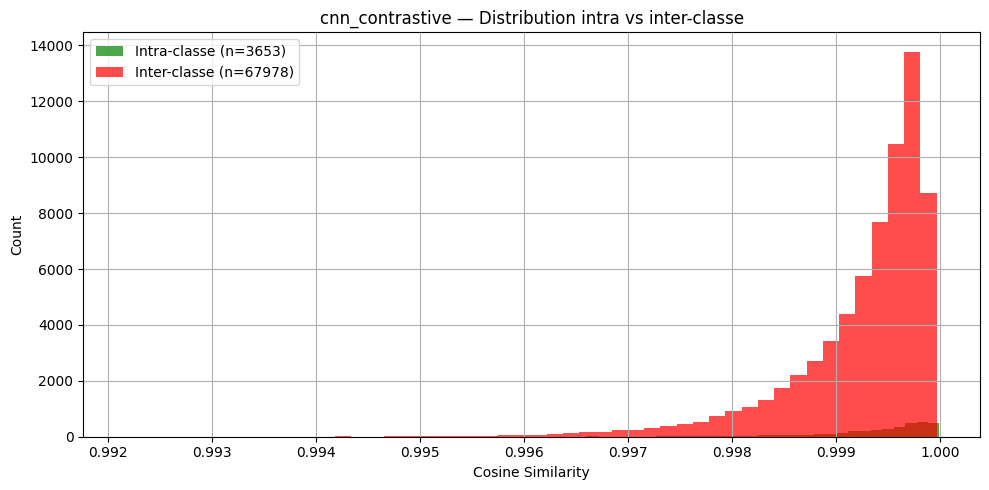

Intra-classe: mean=0.9994, std=0.0006
Inter-classe: mean=0.9993, std=0.0007
Separation: 0.0001


In [10]:
# Distribution des similarités intra-classe vs inter-classe
intra_sims = []
inter_sims = []

for i in range(len(y_val)):
    for j in range(i + 1, len(y_val)):
        s = float(sim_matrix[i, j]) if i != j else float(val_embeddings_norm[i] @ val_embeddings_norm[j])
        if y_val[i] == y_val[j]:
            intra_sims.append(s)
        else:
            inter_sims.append(s)

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(intra_sims, bins=50, alpha=0.7, label=f'Intra-classe (n={len(intra_sims)})', color='green')
ax.hist(inter_sims, bins=50, alpha=0.7, label=f'Inter-classe (n={len(inter_sims)})', color='red')
ax.set_xlabel('Cosine Similarity'); ax.set_ylabel('Count')
ax.set_title(f'{MODEL_NAME} — Distribution intra vs inter-classe')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'{MODEL_NAME}_sim_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"Intra-classe: mean={np.mean(intra_sims):.4f}, std={np.std(intra_sims):.4f}")
print(f"Inter-classe: mean={np.mean(inter_sims):.4f}, std={np.std(inter_sims):.4f}")
print(f"Separation: {np.mean(intra_sims) - np.mean(inter_sims):.4f}")

## 5b. Kaggle submission

In [11]:
# Retrain sur train+val
X_all = np.concatenate([X_train, X_val])
y_all = np.concatenate([y_train, y_val])
all_ds = make_dataset(X_all, y_all, training=True, augmentation=AUGMENTATION, batch_size=CL_BATCH_SIZE)

best_epoch = np.argmin(history.history['val_triplet_loss']) + 1
print(f"Retraining on full dataset ({len(X_all)} images) for {best_epoch} epochs")

final_model = build_embedding_model()
final_trainer = TripletTrainer(final_model, margin=MARGIN)
final_trainer.compile(optimizer=optimizers.Adam(learning_rate=LR))

final_log = os.path.join(LOG_DIR, MODEL_NAME, f'final_{datetime.now().strftime("%Y%m%d-%H%M%S")}')
final_trainer.fit(
    all_ds, epochs=best_epoch,
    callbacks=[callbacks.TensorBoard(log_dir=final_log)],
    verbose=1
)
print("Final retrain done.")

W0000 00:00:1776172721.805196 1856072 cpu_allocator_impl.cc:82] Allocation of 1141002240 exceeds 10% of free system memory.


Retraining on full dataset (1895 images) for 5 epochs
Epoch 1/5


I0000 00:00:1776172729.490219 1856748 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_16929__.95


14/15 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step - triplet_acc: 0.0022 - triplet_loss: 0.4998

I0000 00:00:1776172739.458496 1856749 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_16929__.95
I0000 00:00:1776172739.579203 1856749 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1776172743.225075 1856749 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1776172744.843889 1856749 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1776172745.72192

15/15 ━━━━━━━━━━━━━━━━━━━━ 38s 2s/step - triplet_acc: 0.0022 - triplet_loss: 0.4819
Epoch 2/5
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 105ms/step - triplet_acc: 0.0000e+00 - triplet_loss: 0.4267
Epoch 3/5
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 105ms/step - triplet_acc: 0.0011 - triplet_loss: 0.3988    
Epoch 4/5
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 103ms/step - triplet_acc: 0.0000e+00 - triplet_loss: 0.3836
Epoch 5/5
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 128ms/step - triplet_acc: 5.3763e-04 - triplet_loss: 0.3680
Final retrain done.


In [12]:
X_test, test_filenames = load_data('test')

# Le modèle sort directement des embeddings normalisés — pas besoin d'extraire une couche intermédiaire
test_embeddings = final_model.predict(X_test, batch_size=CL_BATCH_SIZE, verbose=1)
# Already L2-normalized by the Lambda layer, but double-check
test_embeddings_norm = normalize(test_embeddings, axis=1)
print(f"Embedding shape: {test_embeddings_norm.shape}")

del X_test  # free memory

fname_to_idx = {fname: i for i, fname in enumerate(test_filenames)}
query_idx   = test_pairs_df['query_image'].map(fname_to_idx).values
gallery_idx = test_pairs_df['gallery_image'].map(fname_to_idx).values

# Chunked cosine similarity
CHUNK = 1000
similarities = np.empty(len(query_idx), dtype=np.float32)
for start in range(0, len(query_idx), CHUNK):
    sl = slice(start, start + CHUNK)
    q = test_embeddings_norm[query_idx[sl]]
    g = test_embeddings_norm[gallery_idx[sl]]
    similarities[sl] = np.clip((q * g).sum(axis=1), 0, 1)

submission = pd.DataFrame({'row_id': test_pairs_df['row_id'], 'similarity': similarities})
submission_path = os.path.join(SUBMISSION_DIR, f'submission_{MODEL_NAME}.csv')
submission.to_csv(submission_path, index=False)
print(f"Saved: {submission_path}")
display(submission.head())

3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 2s/step 
Embedding shape: (371, 128)
Saved: /HomeSweetHome/FHuang5/Developer/kaggle_jaguar_classification/submissions/submission_cnn_contrastive.csv


,row_id,similarity
0,0,0.999950
1,1,0.999654
2,2,0.999569
3,3,0.998898
4,4,0.999865


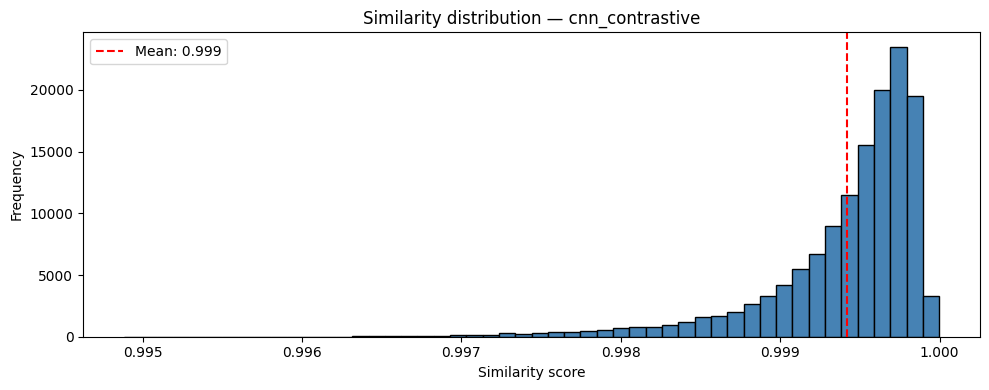

In [13]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(similarities, bins=50, color='steelblue', edgecolor='black')
ax.axvline(similarities.mean(), color='red', linestyle='--', label=f'Mean: {similarities.mean():.3f}')
ax.set_xlabel('Similarity score'); ax.set_ylabel('Frequency')
ax.set_title(f'Similarity distribution — {MODEL_NAME}')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'{MODEL_NAME}_similarity.png'), dpi=150, bbox_inches='tight')
plt.show()

## 6. Observations & Verdict

### Résultats

| Métrique | Valeur |
|----------|--------|
| Triplet Loss (train) | 0.3314 |
| Triplet Loss (val) | 0.3012 (best epoch 5) |
| Triplet Accuracy (train) | ~0.0% |
| Triplet Accuracy (val) | ~2.8% |
| Rank-1 Retrieval Accuracy (val) | 58.31% (221/379) |
| Similarité intra-classe (val) | 0.9994 |
| Similarité inter-classe (val) | 0.9993 |
| Séparation intra - inter | **0.0001** |
| Kaggle Score (public) | 0.200 |
| Kaggle Score (private) | ___ |

### Comparaison : Classification (v5) vs Contrastive (vCL)

| Métrique | v5 (cross-entropy) | vCL (triplet loss) | Diff |
|----------|-------------------|--------------------|------|
| Loss d'entraînement | cross-entropy | triplet (batch-hard) | — |
| Val accuracy / Rank-1 | 91.03% | 58.31% | **−32.7 pts** |
| Kaggle (public) | 0.404 | 0.200 | **−0.204** |
| Séparation intra/inter | N/A | 0.0001 | — |
| Similarités test | 0.0–1.0 (distribuées) | ~0.999 (collapsées) | — |

### Diagnostic : Embedding Collapse

Le résultat le plus révélateur est la distribution des similarités sur le test set : **toutes les paires ont une similarité ~0.999**. Cela signifie que tous les embeddings sont quasi-identiques — le modèle a convergé vers un seul point sur la sphère unitaire. C'est un mode d'échec classique de la triplet loss appelé **embedding collapse**.

**Pourquoi le collapse se produit :**

1. **Triplet accuracy = 0% tout au long du training**. Le modèle n'a jamais réussi à correctement ordonner un seul triplet (d_pos < d_neg). La loss descend (0.50 → 0.33) mais uniquement parce que les distances se resserrent globalement — pas parce que les classes se séparent.

2. **Séparation intra/inter = 0.0001**. La moyenne intra-classe (0.9994) est virtuellement identique à la moyenne inter-classe (0.9993). Le modèle n'a appris aucune structure discriminante dans l'espace d'embedding.

3. **EarlyStopping à epoch 20, best epoch 5**. La val_triplet_loss monte dès epoch 6 (0.3012 → 0.3404), mais pas parce que le modèle overfit — parce qu'il diverge. Le training loss continue de descendre (0.38 → 0.33) mais le modèle mémorise des patterns de bruit au lieu de séparer les classes.

### Pourquoi ça ne marche pas dans notre cas — 3 raisons structurelles

#### 1. Signal superviseur trop faible pour un CNN from scratch

La cross-entropy fournit un gradient dense : à chaque step, chaque image reçoit un signal par rapport aux **31 classes** (logits vs one-hot target). La triplet loss ne fournit qu'un signal **par rapport à 2 images** (hardest positive + hardest negative). Quand le backbone part de poids aléatoires, ce signal est insuffisant pour apprendre simultanément :
- les filtres convolutionnels (bas-niveau : edges, textures)
- la structure de l'espace d'embedding (haut-niveau : identité des jaguars)

La cross-entropy résout le problème 1 en premier, et le problème 2 émerge comme sous-produit (la couche Dense(128) avant softmax). La triplet loss essaie de résoudre les deux en même temps et échoue.

#### 2. Trop peu de positifs par batch pour le mining

Avec 1516 images, 31 classes et batch_size=128 : **~4 images par classe par batch** (et seulement 25 classes représentées). Le "hardest positive" est choisi parmi 3 candidats seulement. Ce mining est extrêmement bruité — le triplet sélectionné n'est probablement pas informatif, et peut même pousser le modèle dans une mauvaise direction.

Pour un batch-hard mining efficace, il faudrait **P classes × K images/classe** avec K ≥ 8–16. Avec 31 classes et ~49 images/classe, il faudrait des batches de 31 × 8 = 248 minimum, ce qui est impossible sur un dataset de 1516 images (chaque batch contiendrait 16% du dataset).

#### 3. Le modèle n'a pas assez de capacité discriminante initiale

En v5, le CNN atteint 91% de val_acc avec cross-entropy — il distingue les 31 jaguars raisonnablement bien. Mais avec triplet loss, il n'a **aucun point de départ discriminant**. Les embeddings aléatoires initiaux ne séparent pas les classes, et le batch-hard mining sélectionne des triplets au hasard, ce qui ne donne aucun gradient utile → collapse.

### Quand le contrastive learning fonctionne — et pourquoi

Cette expérience **ne disqualifie pas** le contrastive learning en général. Il est extrêmement efficace dans d'autres contextes :

| Condition | Notre cas | Cas favorable |
|-----------|-----------|---------------|
| Backbone | From scratch (poids aléatoires) | **Pré-entraîné** (ImageNet) — features de base déjà apprises |
| Dataset | 1516 images, 31 classes | **10K+ images**, 100+ classes |
| Positifs/classe | ~49 | **100+** (permet un mining de qualité) |
| Batch size effectif | 128 (25 classes, ~4 imgs/classe) | **P×K sampling** (ex: 16 classes × 8 imgs = 128) |
| Architecture | CNN simple 5 blocs | ResNet-50/101 avec couches profondes |

La triplet loss excelle quand elle est utilisée pour **fine-tuner** un backbone pré-entraîné : le modèle a déjà des features discriminantes (de la cross-entropy sur ImageNet), et la triplet loss affine la structure de l'espace d'embedding pour le re-ID. C'est l'approche standard en re-ID de personnes (Market-1501, DukeMTMC) et d'animaux (Wildlife Re-ID), toujours avec un backbone pré-entraîné.

Dans notre cas, la cross-entropy "classique" de v5 produit de meilleurs embeddings (Kaggle 0.404) que la triplet loss (0.200), parce que le signal superviseur dense permet au CNN d'apprendre des features utiles malgré le peu de données.

### Verdict

- [ ] Triplet Loss améliore le score Kaggle
- [x] Triplet Loss dégrade le score Kaggle — **embedding collapse, −0.204 pts**
- [ ] Résultats similaires

### Interprétation

_Ce notebook était une **expérimentation** pour tester si optimiser directement la similarité des embeddings (au lieu de passer par la classification) pouvait améliorer le score Kaggle. Le résultat est un échec net (0.200 vs 0.404), causé par un embedding collapse : le modèle converge vers des embeddings identiques pour toutes les images. Ce résultat confirme que la triplet loss nécessite un backbone pré-entraîné pour fonctionner — elle est conçue pour affiner un espace d'embedding déjà structuré, pas pour en construire un from scratch. C'est une leçon importante : la méthode d'entraînement optimale dépend des ressources disponibles (données, features pré-apprises). Avec un ResNet pré-entraîné, cette même triplet loss pourrait potentiellement dépasser la cross-entropy sur notre tâche de re-ID, car elle optimiserait directement ce que Kaggle évalue (la similarité cosinus entre paires)._